In [23]:
!pip -q install imagehash pillow-heif

In [25]:
from pathlib import Path
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor
import hashlib, json, os, random, re, shutil, warnings

import numpy as np
import pandas as pd
from PIL import Image, ImageFile
from tqdm.auto import tqdm
import imagehash

try:
    from pillow_heif import register_heif_opener
    register_heif_opener()
except Exception as e:
    print("HEIF registration warning:", e)

ImageFile.LOAD_TRUNCATED_IMAGES = False
SEED = 42
random.seed(SEED); np.random.seed(SEED)
OUTPUT_DIR = Path('/kaggle/working/defakex_experiment_0_audit')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_EXTS = {'.jpg','.jpeg','.png','.webp','.bmp','.tif','.tiff','.heic','.heif','.dng'}
SPLIT_RATIOS = {'train':0.70, 'validation':0.10, 'locked_test':0.20}

candidate_roots = [
    Path('/kaggle/input/datasets/kashirhanif/defakex_dataset'),
    Path('kaggle/input/datasets/kashirhanif/defakex_dataset'),
    Path('/kaggle/input/defakex_dataset'),
    Path('/kaggle/input/defakex-dataset'),
]

def score_root(p):
    if not p.exists(): return -1
    return int(any(p.rglob('DefakeX_annotations_final.csv'))) * 100000 + sum(1 for x in p.rglob('*') if x.suffix.lower() in IMAGE_EXTS)

ranked = sorted(((score_root(p), p) for p in candidate_roots), reverse=True)
if not ranked or ranked[0][0] < 0:
    extras = [p.parent for p in Path('/kaggle/input').rglob('DefakeX_annotations_final.csv')]
    ranked = sorted(((score_root(p), p) for p in extras), reverse=True)
assert ranked and ranked[0][0] >= 0, 'Dataset not found. Attach it to this Kaggle notebook and verify the path.'
DATA_ROOT = ranked[0][1].resolve()
print('DATA_ROOT:', DATA_ROOT)
print('OUTPUT_DIR:', OUTPUT_DIR)

DATA_ROOT: /kaggle/input/datasets/kashirhanif/defakex-dataset/DefakeX/DefakeX
OUTPUT_DIR: /kaggle/working/defakex_experiment_0_audit


In [26]:
# ============================================================
# USE FINAL CORRECTED MANIFESTS + ORIGINAL IMAGE ARCHIVE
# ============================================================

from pathlib import Path

KAGGLE_INPUT = Path("/kaggle/input")

# Locate the final corrected package
final_reports = list(
    KAGGLE_INPUT.rglob("DefakeX_final_correction_report.json")
)

assert final_reports, (
    "Could not locate DefakeX_final_correction_report.json. "
    "Make sure the updated dataset version is attached."
)

assert len(final_reports) == 1, (
    "Multiple final correction packages were found:\n" +
    "\n".join(str(path) for path in final_reports)
)

FINAL_CORRECTED_ROOT = final_reports[0].parent

# Final authoritative CSV files
ANNOTATION_CSV = (
    FINAL_CORRECTED_ROOT /
    "DefakeX_annotations_final.csv"
)

TRAIN_CSV = (
    FINAL_CORRECTED_ROOT /
    "DefakeX_train.csv"
)

VALIDATION_CSV = (
    FINAL_CORRECTED_ROOT /
    "DefakeX_validation.csv"
)

TEST_CSV = (
    FINAL_CORRECTED_ROOT /
    "DefakeX_test.csv"
)

for path in [
    ANNOTATION_CSV,
    TRAIN_CSV,
    VALIDATION_CSV,
    TEST_CSV
]:
    assert path.exists(), f"Missing corrected file: {path}"


# Locate original image directory
image_root_candidates = []

for real_directory in KAGGLE_INPUT.rglob("real"):
    if not real_directory.is_dir():
        continue

    parent = real_directory.parent

    has_gemini = (parent / "gemini").is_dir()

    has_chatgpt = (
        (parent / "chatgpt").is_dir() or
        (parent / "chatgpt defakex").is_dir()
    )

    if has_gemini and has_chatgpt:
        image_root_candidates.append(parent)

assert image_root_candidates, (
    "Could not locate the original real/gemini/chatgpt image directories."
)


def count_images(root):
    extensions = {
        ".jpg", ".jpeg", ".png", ".webp", ".bmp",
        ".tif", ".tiff", ".heic", ".heif", ".dng"
    }

    return sum(
        1 for path in root.rglob("*")
        if path.is_file() and path.suffix.lower() in extensions
    )


DATA_ROOT = max(
    image_root_candidates,
    key=count_images
)

print("Original image root:")
print(DATA_ROOT)

print("\nFinal corrected manifest root:")
print(FINAL_CORRECTED_ROOT)

print("\nAuthoritative files:")
print("Annotation:", ANNOTATION_CSV)
print("Train:     ", TRAIN_CSV)
print("Validation:", VALIDATION_CSV)
print("Test:      ", TEST_CSV)

Original image root:
/kaggle/input/datasets/kashirhanif/defakex-dataset/DefakeX/DefakeX

Final corrected manifest root:
/kaggle/input/datasets/kashirhanif/defakex-dataset/DefakeX_Experiment0_FINAL_Corrected_Files

Authoritative files:
Annotation: /kaggle/input/datasets/kashirhanif/defakex-dataset/DefakeX_Experiment0_FINAL_Corrected_Files/DefakeX_annotations_final.csv
Train:      /kaggle/input/datasets/kashirhanif/defakex-dataset/DefakeX_Experiment0_FINAL_Corrected_Files/DefakeX_train.csv
Validation: /kaggle/input/datasets/kashirhanif/defakex-dataset/DefakeX_Experiment0_FINAL_Corrected_Files/DefakeX_validation.csv
Test:       /kaggle/input/datasets/kashirhanif/defakex-dataset/DefakeX_Experiment0_FINAL_Corrected_Files/DefakeX_test.csv


In [27]:
# ============================================================
# INVENTORY USING FINAL CORRECTED MANIFEST
# ============================================================

IMAGE_EXTS = {
    ".jpg", ".jpeg", ".png", ".webp", ".bmp",
    ".tif", ".tiff", ".heic", ".heif", ".dng"
}

# These files remain physically inside the original large ZIP,
# but they are intentionally excluded from the final dataset.
IGNORED_RELATIVE_PATHS = {
    "chatgpt/ChatGPT Image Sep 27, 2026, 12_13_19 AM(1).png",
    "real/Mus/Unconfirmed 490142.crdownload.jpg"
}

ignored_normalized = {
    path.replace("\\", "/").lower()
    for path in IGNORED_RELATIVE_PATHS
}


def should_ignore_image(path):
    relative_path = (
        path.relative_to(DATA_ROOT)
        .as_posix()
        .lower()
    )

    return relative_path in ignored_normalized


all_physical_images = sorted(
    path for path in DATA_ROOT.rglob("*")
    if (
        path.is_file() and
        path.suffix.lower() in IMAGE_EXTS
    )
)

image_paths = [
    path for path in all_physical_images
    if not should_ignore_image(path)
]

ignored_images_found = [
    path for path in all_physical_images
    if should_ignore_image(path)
]

assert len(ignored_images_found) == 2, (
    "Expected to find the two intentionally ignored physical files, "
    f"but found {len(ignored_images_found)}."
)

ann = pd.read_csv(
    ANNOTATION_CSV,
    dtype=str,
    keep_default_na=False
)

ann.columns = [
    column.strip().lower()
    for column in ann.columns
]

required = {
    "image_id",
    "filepath",
    "label"
}

assert required.issubset(ann.columns), (
    f"Missing required columns: {required - set(ann.columns)}"
)

ann["_row"] = np.arange(len(ann))

for column in [
    "label",
    "source",
    "generator",
    "annotation_status",
    "exclusion_reason",
    "sha256",
    "file_format",
    "final_split"
]:
    if column not in ann.columns:
        ann[column] = ""

    ann[column] = (
        ann[column]
        .astype(str)
        .str.strip()
    )

ann["label_norm"] = (
    ann["label"]
    .str.lower()
    .replace({
        "ai": "fake",
        "generated": "fake",
        "1": "fake",
        "0": "real"
    })
)

ann["excluded"] = (
    ann["exclusion_reason"].ne("") |
    ann["annotation_status"].str.lower().isin({
        "exclude",
        "excluded",
        "invalid",
        "failed"
    })
)

ann["needs_review"] = (
    ann["annotation_status"]
    .str.lower()
    .isin({
        "pending",
        "review",
        "needs_review",
        "unreviewed"
    })
)

print(f"All physical images in archive: {len(all_physical_images):,}")
print(f"Intentionally ignored files: {len(ignored_images_found):,}")
print(f"Final dataset images: {len(image_paths):,}")
print(f"Corrected annotation rows: {len(ann):,}")
print("Annotation CSV:", ANNOTATION_CSV)

print("\nIgnored physical files:")
for path in ignored_images_found:
    print("-", path.relative_to(DATA_ROOT))

display(
    ann["label_norm"]
    .value_counts(dropna=False)
    .rename("rows")
    .to_frame()
)

All physical images in archive: 6,003
Intentionally ignored files: 2
Final dataset images: 6,001
Corrected annotation rows: 6,001
Annotation CSV: /kaggle/input/datasets/kashirhanif/defakex-dataset/DefakeX_Experiment0_FINAL_Corrected_Files/DefakeX_annotations_final.csv

Ignored physical files:
- chatgpt/ChatGPT Image Sep 27, 2026, 12_13_19 AM(1).png
- real/Mus/Unconfirmed 490142.crdownload.jpg


,rows
label_norm,
fake,3001
real,3000


In [28]:
by_name = defaultdict(list)
by_rel = {}
for p in image_paths:
    by_name[p.name.lower()].append(p)
    by_rel[p.relative_to(DATA_ROOT).as_posix().lower()] = p

def clean_rel(s):
    s = str(s).replace('\\','/').strip()
    low = s.lower()
    markers = ['/real/','/gemini/','/chatgpt defakex/']
    for m in markers:
        if m in low:
            return s[low.index(m)+1:]
    return s.lstrip('/')

def resolve_row(row):
    candidates = [row.get('filepath',''), row.get('image_id','')]
    for raw in candidates:
        rel = clean_rel(raw)
        if rel.lower() in by_rel: return str(by_rel[rel.lower()]), 'relative_exact'
    names = []
    for raw in candidates:
        name = Path(str(raw).replace('\\','/')).name.lower()
        if name: names.append(name)
    matches = {str(p) for n in names for p in by_name.get(n,[])}
    if len(matches) == 1: return matches.pop(), 'unique_basename'
    if len(matches) > 1: return '', 'ambiguous_basename'
    return '', 'unmatched'

resolved = ann.apply(resolve_row, axis=1, result_type='expand')
ann[['resolved_path','path_resolution']] = resolved
display(ann['path_resolution'].value_counts().rename('rows').to_frame())

,rows
path_resolution,
relative_exact,6001


In [29]:
def inspect_image(path_str):
    p = Path(path_str)
    out = {'resolved_path':path_str, 'actual_width':'', 'actual_height':'', 'actual_format':'',
           'mode':'', 'file_bytes':'', 'actual_sha256':'', 'phash':'', 'read_error':''}
    try:
        h = hashlib.sha256()
        with p.open('rb') as f:
            for block in iter(lambda: f.read(1024*1024), b''): h.update(block)
        out['actual_sha256'] = h.hexdigest(); out['file_bytes'] = p.stat().st_size
        with Image.open(p) as im:
            im.load(); out['actual_width'], out['actual_height'] = im.size
            out['actual_format'] = (im.format or p.suffix.lstrip('.')).lower(); out['mode'] = im.mode
            out['phash'] = str(imagehash.phash(im.convert('RGB')))
    except Exception as e:
        out['read_error'] = f'{type(e).__name__}: {e}'
    return out

unique_paths = sorted(set(ann.loc[ann['resolved_path'].ne(''),'resolved_path']))
workers = min(12, max(2, (os.cpu_count() or 2)))
with ThreadPoolExecutor(max_workers=workers) as ex:
    scans = list(tqdm(ex.map(inspect_image, unique_paths), total=len(unique_paths), desc='Auditing images'))
scan = pd.DataFrame(scans)
audit = ann.merge(scan, on='resolved_path', how='left')
audit['included'] = ~audit['excluded']
print('Unreadable resolved images:', int(audit['read_error'].fillna('').ne('').sum()))

Auditing images:   0%|          | 0/6001 [00:00<?, ?it/s]

Unreadable resolved images: 0


In [30]:
def path_family(path):
    s = str(path).replace('\\','/').lower()
    if '/real/' in s: return 'real'
    if '/gemini/' in s: return 'gemini'
    if '/chatgpt defakex/' in s or '/chatgpt/' in s: return 'chatgpt'
    return 'other'

audit['path_family'] = audit['resolved_path'].map(path_family)
audit['path_label_expected'] = np.where(audit['path_family'].eq('real'),'real',np.where(audit['path_family'].isin(['gemini','chatgpt']),'fake',''))
audit['path_label_conflict'] = audit['path_label_expected'].ne('') & audit['label_norm'].ne(audit['path_label_expected'])
audit['sha_mismatch'] = audit['sha256'].ne('') & audit['actual_sha256'].ne('') & audit['sha256'].str.lower().ne(audit['actual_sha256'].str.lower())

resolved_set = set(audit['resolved_path'])
orphans = [str(p) for p in image_paths if str(p) not in resolved_set]
included = audit[audit['included']].copy()
sha_stats = included[included['actual_sha256'].ne('')].groupby('actual_sha256').agg(rows=('image_id','size'), labels=('label_norm','nunique')).reset_index()
ph_stats = included[included['phash'].ne('')].groupby('phash').agg(rows=('image_id','size'), labels=('label_norm','nunique')).reset_index()

issues=[]
def add(mask, kind, severity):
    for _,r in audit.loc[mask].iterrows():
        issues.append({'severity':severity,'issue':kind,'image_id':r['image_id'],'filepath':r['filepath'],'resolved_path':r['resolved_path']})
add(audit['included'] & audit['resolved_path'].eq(''), 'unresolved_included_annotation', 'critical')
add(audit['included'] & audit['read_error'].fillna('').ne(''), 'unreadable_included_image', 'critical')
add(audit['included'] & ~audit['label_norm'].isin(['real','fake']), 'invalid_label', 'critical')
add(audit['included'] & audit['path_label_conflict'], 'path_label_conflict', 'critical')
add(audit['included'] & audit['sha_mismatch'], 'annotation_sha256_mismatch', 'warning')
add(audit['needs_review'], 'annotation_needs_review', 'warning')
for p in orphans: issues.append({'severity':'warning','issue':'unannotated_image_file','image_id':'','filepath':'','resolved_path':p})
for h in sha_stats.loc[sha_stats['labels'].gt(1),'actual_sha256']:
    for _,r in included[included['actual_sha256'].eq(h)].iterrows(): issues.append({'severity':'critical','issue':'exact_duplicate_cross_label','image_id':r['image_id'],'filepath':r['filepath'],'resolved_path':r['resolved_path']})

issues_df = pd.DataFrame(issues, columns=['severity','issue','image_id','filepath','resolved_path'])
display(issues_df.groupby(['severity','issue']).size().rename('count').to_frame() if len(issues_df) else pd.DataFrame({'count':[]}))

,count


In [35]:
def identity_from_path(path, label, sha, image_id):
    if sha: duplicate_group = 'sha:'+sha
    else: duplicate_group = 'img:'+str(image_id)
    if label != 'real': return duplicate_group
    try:
        rel = Path(path).relative_to(DATA_ROOT).parts
        low = [x.lower() for x in rel]
        i = low.index('real')
        return 'real_identity:' + (rel[i+1] if i+1 < len(rel)-1 else Path(path).stem)
    except Exception: return duplicate_group

included['identity_group'] = [identity_from_path(p,l,h,i) for p,l,h,i in zip(included['resolved_path'],included['label_norm'],included['actual_sha256'],included['image_id'])]
included['stratum'] = np.where(included['label_norm'].eq('real'),'real',np.where(included['path_family'].eq('gemini'),'fake_gemini',np.where(included['path_family'].eq('chatgpt'),'fake_chatgpt','fake_other')))

existing_split_col = next((c for c in [
            "final_split",
            "split",
            "dataset_split",
            "set"
        ] if c in included.columns and included[c].astype(str).str.strip().ne('').any()), None)
if existing_split_col:
    included['final_split'] = included[existing_split_col].str.lower().replace({'val':'validation','valid':'validation','test':'locked_test'})
    split_origin = f'existing column: {existing_split_col}'
else:
    manifest_files=[]
    for p in DATA_ROOT.rglob('*.csv'):
        n=p.stem.lower()
        split = 'train' if re.search(r'(^|_)train($|_)',n) else ('validation' if re.search(r'(^|_)(val|validation)($|_)',n) else ('locked_test' if re.search(r'(^|_)(test|locked_test)($|_)',n) else None))
        if split and p != ANNOTATION_CSV: manifest_files.append((p,split))
    id_to_split={}; name_to_splits=defaultdict(set)
    for p,split in manifest_files:
        m=pd.read_csv(p,dtype=str,keep_default_na=False); m.columns=[c.strip().lower() for c in m.columns]
        if 'image_id' in m:
            for v in m['image_id'].astype(str): id_to_split[v.strip()]=split
        for col in ['resolved_path','filepath','path']:
            if col in m:
                for v in m[col].astype(str): name_to_splits[Path(v.replace('\\','/')).name.lower()].add(split)
    def lookup_existing(r):
        if str(r['image_id']).strip() in id_to_split: return id_to_split[str(r['image_id']).strip()]
        vals=name_to_splits.get(Path(str(r['resolved_path'])).name.lower(),set())
        return next(iter(vals)) if len(vals)==1 else ''
    from_manifests = included.apply(lookup_existing,axis=1) if manifest_files else pd.Series('',index=included.index)
    if manifest_files and from_manifests.ne('').all():
        included['final_split']=from_manifests
        split_origin='existing manifest files: '+', '.join(sorted(p.name for p,_ in manifest_files))
    else:
        if manifest_files: print('WARNING: existing manifests did not cover every included row; creating a proposal instead.')
        rng = np.random.default_rng(SEED)
        assignments={}
        for stratum, part in included.groupby('stratum'):
            sizes = part.groupby('identity_group').size().to_dict()
            groups = list(sizes); rng.shuffle(groups); groups.sort(key=lambda g:sizes[g], reverse=True)
            target={s:len(part)*r for s,r in SPLIT_RATIOS.items()}; used={s:0 for s in target}
            for g in groups:
                choice=max(target, key=lambda s:(target[s]-used[s])/max(target[s],1))
                assignments[(stratum,g)]=choice; used[choice]+=sizes[g]
        included['final_split']=[assignments[(s,g)] for s,g in zip(included['stratum'],included['identity_group'])]
        split_origin='deterministic group-aware proposal (seed 42)'

# Remove columns already present before attaching the audited split data.
# This prevents final_split_x and final_split_y from being created.
audit = audit.drop(
    columns=[
        "identity_group",
        "stratum",
        "final_split"
    ],
    errors="ignore"
)

audit = audit.merge(
    included[
        [
            "_row",
            "identity_group",
            "stratum",
            "final_split"
        ]
    ],
    on="_row",
    how="left",
    validate="one_to_one"
)
print('Split source:', split_origin)
display(pd.crosstab([included['label_norm'],included['stratum']], included['final_split'], margins=True))

Split source: existing column: final_split


final_split              locked_test  train  validation   All
label_norm stratum                                           
fake       fake_chatgpt          225   1050         225  1500
           fake_gemini           225   1051         225  1501
real       real                  448   2093         449  2990
All                              898   4194         899  5991

In [36]:
valid_split = included[included['final_split'].isin(SPLIT_RATIOS)]
sha_leak = valid_split[valid_split['actual_sha256'].ne('')].groupby('actual_sha256')['final_split'].nunique()
phash_leak = valid_split[valid_split['phash'].ne('')].groupby('phash')['final_split'].nunique()
identity_leak = valid_split[valid_split['label_norm'].eq('real')].groupby('identity_group')['final_split'].nunique()

gates = {
 'included_rows_resolve': int((included['resolved_path'].eq('')).sum()) == 0,
 'included_images_readable': int(included['read_error'].fillna('').ne('').sum()) == 0,
 'labels_are_real_or_fake': included['label_norm'].isin(['real','fake']).all(),
 'no_path_label_conflicts': int(included['path_label_conflict'].sum()) == 0,
 'no_exact_cross_label_duplicates': int((sha_stats['labels']>1).sum()) == 0,
 'no_exact_duplicate_split_leakage': int((sha_leak>1).sum()) == 0,
 'no_real_identity_split_leakage': int((identity_leak>1).sum()) == 0,
 'all_three_splits_present': set(SPLIT_RATIOS).issubset(set(valid_split['final_split'])),
 'no_pending_annotations': int(included['needs_review'].sum()) == 0,
}
gate_df = pd.DataFrame({'gate':gates.keys(),'pass':gates.values()})
display(gate_df.style.applymap(lambda x:'background-color:#c6efce' if x is True else ('background-color:#ffc7ce' if x is False else ''), subset=['pass']))
print('Perceptual-hash groups crossing splits (review candidates):', int((phash_leak>1).sum()))

/tmp/ipykernel_47/1048795014.py:18: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  display(gate_df.style.applymap(lambda x:'background-color:#c6efce' if x is True else ('background-color:#ffc7ce' if x is False else ''), subset=['pass']))


,gate,pass
0,included_rows_resolve,True
1,included_images_readable,True
2,labels_are_real_or_fake,True
3,no_path_label_conflicts,True
4,no_exact_cross_label_duplicates,True
5,no_exact_duplicate_split_leakage,True
6,no_real_identity_split_leakage,True
7,all_three_splits_present,True
8,no_pending_annotations,True


Perceptual-hash groups crossing splits (review candidates): 0


In [37]:
for col in ['label_norm','source','generator','path_family','file_format','actual_format','framing','lighting','face_count','annotation_status']:
    if col in included.columns:
        print('\n###', col)
        display(included[col].replace('', '(blank)').value_counts(dropna=False).rename('count').to_frame().head(30))

print('Resolution summary:')
display(included[['actual_width','actual_height','file_bytes']].apply(pd.to_numeric, errors='coerce').describe().round(1))


### label_norm


,count
label_norm,
fake,3001
real,2990



### source


,count
source,
phone,1627
gemini,1501
chatgpt,1500
whatsapp,1363



### generator


...

,count
face_count,
1,3126
2+,2534
0,331



### annotation_status


,count
annotation_status,
automated_visual_review,5925
visually_reviewed,66


Resolution summary:


,actual_width,actual_height,file_bytes
count,5991.0,5991.0,5991.0
mean,2035.1,1765.2,2420833.2
std,1422.5,1243.0,2676861.2
min,256.0,240.0,11955.0
25%,1200.0,768.0,709303.5
50%,1408.0,1172.0,2100651.0
75%,2816.0,2436.5,2725893.0
max,10608.0,8160.0,27944102.0


In [38]:
manifest_cols = [c for c in ['image_id','filepath','resolved_path','label_norm','source','generator','face_count','framing','lighting','annotation_status','exclusion_reason','actual_width','actual_height','actual_format','file_bytes','actual_sha256','phash','identity_group','stratum','final_split','path_resolution','read_error'] if c in audit.columns]
audit[manifest_cols].to_csv(OUTPUT_DIR/'DefakeX_Experiment0_Audited_Manifest.csv', index=False)
for split, name in [('train','Train'),('validation','Validation'),('locked_test','Locked_Test')]:
    audit[audit['final_split'].eq(split)][manifest_cols].to_csv(OUTPUT_DIR/f'DefakeX_Experiment0_{name}.csv', index=False)
issues_df.to_csv(OUTPUT_DIR/'DefakeX_Experiment0_Issues.csv', index=False)

dups = included[included['actual_sha256'].isin(sha_stats.loc[sha_stats['rows'].gt(1),'actual_sha256'])]
dups[manifest_cols].to_csv(OUTPUT_DIR/'DefakeX_Experiment0_Exact_Duplicate_Groups.csv', index=False)

summary = {
 'experiment':'DefakeX Experiment 0', 'seed':SEED, 'data_root':str(DATA_ROOT), 'annotation_csv':str(ANNOTATION_CSV),
 'image_files_found':len(image_paths), 'annotation_rows':len(ann), 'included_rows':len(included), 'excluded_rows':int(audit['excluded'].sum()),
 'unannotated_image_files':len(orphans), 'split_origin':split_origin,
 'split_counts':valid_split.groupby(['final_split','label_norm']).size().unstack(fill_value=0).to_dict(orient='index'),
 'critical_issue_rows':int((issues_df['severity']=='critical').sum()), 'warning_issue_rows':int((issues_df['severity']=='warning').sum()),
 'perceptual_hash_groups_crossing_splits':int((phash_leak>1).sum()), 'gates':{k:bool(v) for k,v in gates.items()},
 'all_critical_gates_pass':bool(all(gates.values()))
}
(OUTPUT_DIR/'DefakeX_Experiment0_Summary.json').write_text(json.dumps(summary, indent=2))
(OUTPUT_DIR/'README.txt').write_text('DefakeX Experiment 0 audit outputs. The Locked_Test manifest must remain untouched by training, threshold selection, calibration, and model selection.\n')

zip_path = Path('/kaggle/working/DefakeX_Experiment0_Audit_Outputs')
shutil.make_archive(str(zip_path), 'zip', OUTPUT_DIR)
print(json.dumps(summary, indent=2))
print('\nZIP:', str(zip_path)+'.zip')
from IPython.display import FileLink, display
display(FileLink(str(zip_path)+'.zip'))

{
  "experiment": "DefakeX Experiment 0",
  "seed": 42,
  "data_root": "/kaggle/input/datasets/kashirhanif/defakex-dataset/DefakeX/DefakeX",
  "annotation_csv": "/kaggle/input/datasets/kashirhanif/defakex-dataset/DefakeX_Experiment0_FINAL_Corrected_Files/DefakeX_annotations_final.csv",
  "image_files_found": 6001,
  "annotation_rows": 6001,
  "included_rows": 5991,
  "excluded_rows": 10,
  "unannotated_image_files": 0,
  "split_origin": "existing column: final_split",
  "split_counts": {
    "locked_test": {
      "fake": 450,
      "real": 448
    },
    "train": {
      "fake": 2101,
      "real": 2093
    },
    "validation": {
      "fake": 450,
      "real": 449
    }
  },
  "critical_issue_rows": 0,
  "warning_issue_rows": 0,
  "perceptual_hash_groups_crossing_splits": 0,
  "gates": {
    "included_rows_resolve": true,
    "included_images_readable": true,
    "labels_are_real_or_fake": true,
    "no_path_label_conflicts": true,
    "no_exact_cross_label_duplicates": true,
    "n

/kaggle/working/DefakeX_Experiment0_Audit_Outputs.zip

In [11]:
print("=== CRITICAL AND WARNING ISSUES ===")
display(
    issues_df[
        [
            "severity",
            "issue",
            "image_id",
            "filepath",
            "resolved_path"
        ]
    ]
)

print("\n=== DUPLICATED ANNOTATION PATHS ===")
duplicate_annotation_paths = audit[
    audit["resolved_path"].ne("") &
    audit["resolved_path"].duplicated(keep=False)
].sort_values("resolved_path")

display(
    duplicate_annotation_paths[
        [
            "image_id",
            "filepath",
            "resolved_path",
            "label_norm",
            "excluded",
            "final_split"
        ]
    ]
)

print("\n=== PERCEPTUAL HASHES CROSSING SPLITS ===")
crossing_phashes = phash_leak[phash_leak > 1].index.tolist()

display(
    valid_split[
        valid_split["phash"].isin(crossing_phashes)
    ][
        [
            "image_id",
            "filepath",
            "resolved_path",
            "label_norm",
            "path_family",
            "actual_sha256",
            "phash",
            "identity_group",
            "final_split"
        ]
    ].sort_values(["phash", "final_split"])
)

=== CRITICAL AND WARNING ISSUES ===


,severity,issue,image_id,filepath,resolved_path
0,critical,unreadable_included_image,1BkwKuSqp7WVRkwWx_VRkEgTkeh566chf,real/Mus/Unconfirmed 490142.crdownload.jpg,/kaggle/input/datasets/kashirhanif/defakex-dat...
1,warning,unannotated_image_file,,,/kaggle/input/datasets/kashirhanif/defakex-dat...



=== DUPLICATED ANNOTATION PATHS ===


,image_id,filepath,resolved_path,label_norm,excluded,final_split
4566,1rCi4JKoEzXONkXR3WYVRjsEbYtBDsg_6,"chatgpt/ChatGPT Image Sep 27, 2026, 12_13_19 A...",/kaggle/input/datasets/kashirhanif/defakex-dat...,fake,False,train
4567,1ehHsZVuz2MSelEYzVZGI5yzquV9wlUzZ,"chatgpt/ChatGPT Image Sep 27, 2026, 12_13_19 A...",/kaggle/input/datasets/kashirhanif/defakex-dat...,fake,False,train



=== PERCEPTUAL HASHES CROSSING SPLITS ===


,image_id,filepath,resolved_path,label_norm,path_family,actual_sha256,phash,identity_group,final_split
1307,1I-ApMDSOvUsC1jozQGHOtYYHvodiv7kV,real/lea/WhatsApp Image 2026-09-02 at 2.18.39 ...,/kaggle/input/datasets/kashirhanif/defakex-dat...,real,real,1aaedaadbfb7e7895c964809d3fd1c4025bfa7ff297f62...,fbf1710448f34c39,real_identity:lea,train
4568,1OxdXNlSdPZpxRPmCR7J_s7lJeFDRnsQU,"chatgpt/ChatGPT Image Sep 27, 2026, 12_13_16 A...",/kaggle/input/datasets/kashirhanif/defakex-dat...,fake,chatgpt,351fdd296f05a2a9a51551c813437bf743b279813f53f6...,fbf1710448f34c39,sha:351fdd296f05a2a9a51551c813437bf743b279813f...,validation


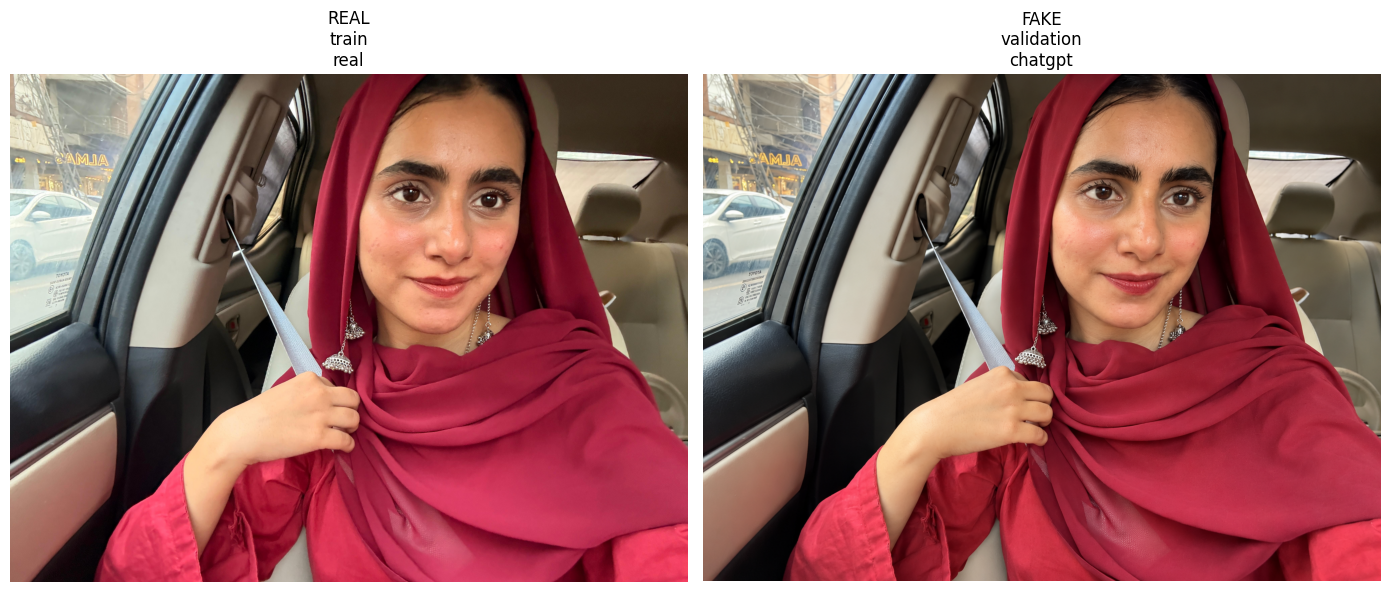

,image_id,filepath,label_norm,path_family,final_split,phash
1307,1I-ApMDSOvUsC1jozQGHOtYYHvodiv7kV,real/lea/WhatsApp Image 2026-09-02 at 2.18.39 ...,real,real,train,fbf1710448f34c39
4568,1OxdXNlSdPZpxRPmCR7J_s7lJeFDRnsQU,"chatgpt/ChatGPT Image Sep 27, 2026, 12_13_16 A...",fake,chatgpt,validation,fbf1710448f34c39


In [12]:
from PIL import Image
import matplotlib.pyplot as plt

pair = valid_split[
    valid_split["phash"] == "fbf1710448f34c39"
].copy()

fig, axes = plt.subplots(1, len(pair), figsize=(14, 7))

for ax, (_, row) in zip(axes, pair.iterrows()):
    with Image.open(row["resolved_path"]) as img:
        ax.imshow(img.convert("RGB"))

    ax.set_title(
        f'{row["label_norm"].upper()}\n'
        f'{row["final_split"]}\n'
        f'{row["path_family"]}'
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

display(
    pair[
        [
            "image_id",
            "filepath",
            "label_norm",
            "path_family",
            "final_split",
            "phash"
        ]
    ]
)

In [13]:
# ============================================================
# DEFAKEX — FIX INTENTIONAL REAL/AI-EDIT PAIR SPLIT LEAKAGE
# Run after completing all Experiment 0 cells
# ============================================================

from pathlib import Path
import json
import shutil
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------

REAL_PARENT_ID = "1I-ApMDSOvUsC1jozQGHOtYYHvodiv7kV"
AI_EDIT_ID = "1OxdXNlSdPZpxRPmCR7J_s7lJeFDRnsQU"

FIXED_DIR = Path("/kaggle/working/defakex_experiment_0_corrected")
FIXED_DIR.mkdir(parents=True, exist_ok=True)

print("Real parent:", REAL_PARENT_ID)
print("AI-edited image:", AI_EDIT_ID)


# ------------------------------------------------------------
# 2. Validate the current pair
# ------------------------------------------------------------

pair_before = included[
    included["image_id"].isin([REAL_PARENT_ID, AI_EDIT_ID])
][
    [
        "image_id",
        "filepath",
        "label_norm",
        "path_family",
        "actual_sha256",
        "phash",
        "identity_group",
        "final_split"
    ]
].copy()

assert len(pair_before) == 2, (
    f"Expected two paired images, but found {len(pair_before)}."
)

real_row = pair_before[
    pair_before["image_id"] == REAL_PARENT_ID
].iloc[0]

fake_row = pair_before[
    pair_before["image_id"] == AI_EDIT_ID
].iloc[0]

assert real_row["label_norm"] == "real"
assert fake_row["label_norm"] == "fake"
assert fake_row["path_family"] == "chatgpt"
assert real_row["final_split"] == "train"
assert fake_row["final_split"] == "validation"

print("\nCurrent problematic pair:")
display(pair_before)


# ------------------------------------------------------------
# 3. Select a safe ChatGPT training replacement
# ------------------------------------------------------------

# Candidate must:
# - Be ChatGPT fake
# - Currently belong to training
# - Have a valid pHash and SHA-256
# - Have a globally unique pHash
# - Have a globally unique SHA-256
# - Not be the paired AI edit

phash_counts = included.loc[
    included["phash"].fillna("").ne(""),
    "phash"
].value_counts()

sha_counts = included.loc[
    included["actual_sha256"].fillna("").ne(""),
    "actual_sha256"
].value_counts()

candidate_pool = included[
    (included["image_id"] != AI_EDIT_ID) &
    (included["label_norm"] == "fake") &
    (included["path_family"] == "chatgpt") &
    (included["final_split"] == "train") &
    (included["phash"].fillna("").ne("")) &
    (included["actual_sha256"].fillna("").ne(""))
].copy()

candidate_pool["phash_count"] = (
    candidate_pool["phash"].map(phash_counts).fillna(0)
)

candidate_pool["sha_count"] = (
    candidate_pool["actual_sha256"].map(sha_counts).fillna(0)
)

candidate_pool = candidate_pool[
    (candidate_pool["phash_count"] == 1) &
    (candidate_pool["sha_count"] == 1)
].copy()

assert len(candidate_pool) > 0, (
    "No safe ChatGPT training replacement candidate was found."
)


# ------------------------------------------------------------
# 4. Prefer a candidate visually distant from all real images
# ------------------------------------------------------------

real_phashes = (
    included.loc[
        (included["label_norm"] == "real") &
        (included["phash"].fillna("").ne("")),
        "phash"
    ]
    .drop_duplicates()
    .tolist()
)

real_phash_ints = [int(value, 16) for value in real_phashes]


def minimum_real_phash_distance(phash_hex):
    """Minimum 64-bit pHash Hamming distance from any real image."""

    value = int(phash_hex, 16)

    return min(
        (value ^ real_value).bit_count()
        for real_value in real_phash_ints
    )


candidate_pool["minimum_real_phash_distance"] = (
    candidate_pool["phash"].map(minimum_real_phash_distance)
)

# Deterministic selection:
# Prefer the candidate most visually distant from all real images.
candidate_pool = candidate_pool.sort_values(
    by=[
        "minimum_real_phash_distance",
        "image_id"
    ],
    ascending=[
        False,
        True
    ]
)

replacement = candidate_pool.iloc[0]
REPLACEMENT_ID = replacement["image_id"]

print("\nSelected replacement ChatGPT image:")
display(
    replacement[
        [
            "image_id",
            "filepath",
            "label_norm",
            "path_family",
            "actual_sha256",
            "phash",
            "minimum_real_phash_distance",
            "final_split"
        ]
    ].to_frame().T
)


# ------------------------------------------------------------
# 5. Apply the swap in memory
# ------------------------------------------------------------

# AI edit: validation -> train
included.loc[
    included["image_id"] == AI_EDIT_ID,
    "final_split"
] = "train"

# Unrelated ChatGPT image: train -> validation
included.loc[
    included["image_id"] == REPLACEMENT_ID,
    "final_split"
] = "validation"

# Update audit dataframe using image_id
split_mapping = included.set_index("image_id")["final_split"]

audit["final_split"] = (
    audit["image_id"]
    .map(split_mapping)
    .fillna(audit["final_split"])
)

pair_after = included[
    included["image_id"].isin(
        [REAL_PARENT_ID, AI_EDIT_ID, REPLACEMENT_ID]
    )
][
    [
        "image_id",
        "filepath",
        "label_norm",
        "path_family",
        "phash",
        "identity_group",
        "final_split"
    ]
].copy()

print("\nSplit assignments after correction:")
display(pair_after)


# ------------------------------------------------------------
# 6. Add AI-edit provenance metadata
# ------------------------------------------------------------

for dataframe in [included, audit]:
    for column in [
        "manipulation_type",
        "parent_image_id",
        "provenance_group"
    ]:
        if column not in dataframe.columns:
            dataframe[column] = ""

    dataframe.loc[
        dataframe["image_id"] == AI_EDIT_ID,
        "manipulation_type"
    ] = "ai_edit"

    dataframe.loc[
        dataframe["image_id"] == AI_EDIT_ID,
        "parent_image_id"
    ] = REAL_PARENT_ID

    dataframe.loc[
        dataframe["image_id"].isin([REAL_PARENT_ID, AI_EDIT_ID]),
        "provenance_group"
    ] = f"pair:{REAL_PARENT_ID}"


# ------------------------------------------------------------
# 7. Update copies of the original split CSV files
# ------------------------------------------------------------

def locate_csv(filename):
    matches = list(DATA_ROOT.rglob(filename))

    assert matches, f"Could not locate {filename}"

    return matches[0]


source_train_path = locate_csv("DefakeX_train.csv")
source_validation_path = locate_csv("DefakeX_validation.csv")
source_test_path = locate_csv("DefakeX_test.csv")

source_train = pd.read_csv(
    source_train_path,
    dtype=str,
    keep_default_na=False
)

source_validation = pd.read_csv(
    source_validation_path,
    dtype=str,
    keep_default_na=False
)

source_test = pd.read_csv(
    source_test_path,
    dtype=str,
    keep_default_na=False
)

for dataframe, name in [
    (source_train, "train"),
    (source_validation, "validation"),
    (source_test, "test")
]:
    assert "image_id" in dataframe.columns, (
        f"{name} manifest does not contain image_id."
    )

# Extract both rows from their original manifests
ai_edit_manifest_row = source_validation[
    source_validation["image_id"] == AI_EDIT_ID
].copy()

replacement_manifest_row = source_train[
    source_train["image_id"] == REPLACEMENT_ID
].copy()

assert len(ai_edit_manifest_row) == 1, (
    "AI-edited image was not found exactly once in validation CSV."
)

assert len(replacement_manifest_row) == 1, (
    "Replacement image was not found exactly once in training CSV."
)

# Remove images from original locations
fixed_train = source_train[
    source_train["image_id"] != REPLACEMENT_ID
].copy()

fixed_validation = source_validation[
    source_validation["image_id"] != AI_EDIT_ID
].copy()

# Swap them
fixed_train = pd.concat(
    [fixed_train, ai_edit_manifest_row],
    ignore_index=True
)

fixed_validation = pd.concat(
    [fixed_validation, replacement_manifest_row],
    ignore_index=True
)

fixed_test = source_test.copy()

# Update split columns when present
for dataframe, split_name in [
    (fixed_train, "train"),
    (fixed_validation, "validation"),
    (fixed_test, "locked_test")
]:
    for split_column in ["split", "dataset_split", "set", "final_split"]:
        if split_column in dataframe.columns:
            dataframe[split_column] = split_name

# Deterministic ordering
fixed_train = fixed_train.sort_values("image_id").reset_index(drop=True)
fixed_validation = fixed_validation.sort_values("image_id").reset_index(drop=True)
fixed_test = fixed_test.sort_values("image_id").reset_index(drop=True)

fixed_train.to_csv(
    FIXED_DIR / "DefakeX_train.csv",
    index=False
)

fixed_validation.to_csv(
    FIXED_DIR / "DefakeX_validation.csv",
    index=False
)

fixed_test.to_csv(
    FIXED_DIR / "DefakeX_test.csv",
    index=False
)


# ------------------------------------------------------------
# 8. Export corrected annotation CSV
# ------------------------------------------------------------

corrected_annotations = ann.copy()

corrected_annotations["final_split"] = (
    corrected_annotations["image_id"]
    .map(split_mapping)
    .fillna("")
)

for column in [
    "manipulation_type",
    "parent_image_id",
    "provenance_group"
]:
    if column not in corrected_annotations.columns:
        corrected_annotations[column] = ""

corrected_annotations.loc[
    corrected_annotations["image_id"] == AI_EDIT_ID,
    "manipulation_type"
] = "ai_edit"

corrected_annotations.loc[
    corrected_annotations["image_id"] == AI_EDIT_ID,
    "parent_image_id"
] = REAL_PARENT_ID

corrected_annotations.loc[
    corrected_annotations["image_id"].isin(
        [REAL_PARENT_ID, AI_EDIT_ID]
    ),
    "provenance_group"
] = f"pair:{REAL_PARENT_ID}"

corrected_annotations.to_csv(
    FIXED_DIR / "DefakeX_annotations_final.csv",
    index=False
)


# ------------------------------------------------------------
# 9. Export corrected audited manifests
# ------------------------------------------------------------

export_columns = [
    column for column in [
        "image_id",
        "filepath",
        "resolved_path",
        "label_norm",
        "source",
        "generator",
        "face_count",
        "framing",
        "lighting",
        "annotation_status",
        "exclusion_reason",
        "actual_width",
        "actual_height",
        "actual_format",
        "file_bytes",
        "actual_sha256",
        "phash",
        "identity_group",
        "stratum",
        "final_split",
        "manipulation_type",
        "parent_image_id",
        "provenance_group",
        "path_resolution",
        "read_error"
    ]
    if column in audit.columns
]

audit[export_columns].to_csv(
    FIXED_DIR / "DefakeX_Experiment0_Audited_Manifest.csv",
    index=False
)

for split_name, output_name in [
    ("train", "Train"),
    ("validation", "Validation"),
    ("locked_test", "Locked_Test")
]:
    audit[
        audit["final_split"] == split_name
    ][export_columns].to_csv(
        FIXED_DIR / f"DefakeX_Experiment0_{output_name}.csv",
        index=False
    )


# ------------------------------------------------------------
# 10. Rerun leakage checks
# ------------------------------------------------------------

valid_split_fixed = included[
    included["final_split"].isin(
        ["train", "validation", "locked_test"]
    )
].copy()

sha_split_counts = (
    valid_split_fixed[
        valid_split_fixed["actual_sha256"].fillna("").ne("")
    ]
    .groupby("actual_sha256")["final_split"]
    .nunique()
)

phash_split_counts = (
    valid_split_fixed[
        valid_split_fixed["phash"].fillna("").ne("")
    ]
    .groupby("phash")["final_split"]
    .nunique()
)

real_identity_split_counts = (
    valid_split_fixed[
        valid_split_fixed["label_norm"] == "real"
    ]
    .groupby("identity_group")["final_split"]
    .nunique()
)

provenance_split_counts = (
    valid_split_fixed[
        valid_split_fixed["provenance_group"].fillna("").ne("")
    ]
    .groupby("provenance_group")["final_split"]
    .nunique()
)

exact_hash_leakage = sha_split_counts[
    sha_split_counts > 1
]

perceptual_hash_leakage = phash_split_counts[
    phash_split_counts > 1
]

identity_leakage = real_identity_split_counts[
    real_identity_split_counts > 1
]

provenance_leakage = provenance_split_counts[
    provenance_split_counts > 1
]


# ------------------------------------------------------------
# 11. Validate counts and generator balance
# ------------------------------------------------------------

new_split_table = pd.crosstab(
    [
        valid_split_fixed["label_norm"],
        valid_split_fixed["path_family"]
    ],
    valid_split_fixed["final_split"],
    margins=True
)

print("\nCorrected split distribution:")
display(new_split_table)

assert len(fixed_train) == len(source_train), (
    "Training count changed unexpectedly."
)

assert len(fixed_validation) == len(source_validation), (
    "Validation count changed unexpectedly."
)

assert len(fixed_test) == len(source_test), (
    "Test count changed unexpectedly."
)

assert (
    included.loc[
        included["image_id"] == REAL_PARENT_ID,
        "final_split"
    ].iloc[0]
    ==
    included.loc[
        included["image_id"] == AI_EDIT_ID,
        "final_split"
    ].iloc[0]
), "Real/AI-edit pair is still split across partitions."


# ------------------------------------------------------------
# 12. Final correction report
# ------------------------------------------------------------

correction_gates = {
    "real_and_ai_edit_are_together":
        included.loc[
            included["image_id"] == REAL_PARENT_ID,
            "final_split"
        ].iloc[0]
        ==
        included.loc[
            included["image_id"] == AI_EDIT_ID,
            "final_split"
        ].iloc[0],

    "no_exact_hash_split_leakage":
        len(exact_hash_leakage) == 0,

    "no_perceptual_hash_split_leakage":
        len(perceptual_hash_leakage) == 0,

    "no_real_identity_split_leakage":
        len(identity_leakage) == 0,

    "no_provenance_group_split_leakage":
        len(provenance_leakage) == 0,

    "training_count_preserved":
        len(fixed_train) == len(source_train),

    "validation_count_preserved":
        len(fixed_validation) == len(source_validation),

    "test_count_preserved":
        len(fixed_test) == len(source_test)
}

correction_report = {
    "real_parent_image_id": REAL_PARENT_ID,
    "ai_edited_image_id": AI_EDIT_ID,
    "replacement_image_id": REPLACEMENT_ID,
    "replacement_minimum_real_phash_distance":
        int(replacement["minimum_real_phash_distance"]),
    "correction_gates": {
        key: bool(value)
        for key, value in correction_gates.items()
    },
    "all_split_correction_gates_pass":
        bool(all(correction_gates.values())),
    "remaining_unreadable_images":
        int(
            included["read_error"]
            .fillna("")
            .ne("")
            .sum()
        )
}

with open(
    FIXED_DIR / "DefakeX_split_correction_report.json",
    "w"
) as file:
    json.dump(correction_report, file, indent=2)

print("\nCorrection report:")
print(json.dumps(correction_report, indent=2))


# ------------------------------------------------------------
# 13. Show any remaining leakage
# ------------------------------------------------------------

if len(perceptual_hash_leakage) > 0:
    print("\nRemaining perceptual-hash leakage:")
    display(
        valid_split_fixed[
            valid_split_fixed["phash"].isin(
                perceptual_hash_leakage.index
            )
        ][
            [
                "image_id",
                "filepath",
                "label_norm",
                "path_family",
                "phash",
                "final_split"
            ]
        ].sort_values(["phash", "final_split"])
    )
else:
    print("\nPASS: No perceptual-hash group crosses splits.")

if len(exact_hash_leakage) == 0:
    print("PASS: No exact SHA-256 duplicate crosses splits.")
else:
    print("FAIL: Exact SHA-256 leakage still exists.")
    display(exact_hash_leakage)

if len(identity_leakage) == 0:
    print("PASS: No real identity group crosses splits.")
else:
    print("FAIL: Real identity leakage still exists.")
    display(identity_leakage)

if len(provenance_leakage) == 0:
    print("PASS: No real/AI-edit provenance group crosses splits.")
else:
    print("FAIL: Provenance leakage still exists.")
    display(provenance_leakage)


# ------------------------------------------------------------
# 14. Create downloadable corrected ZIP
# ------------------------------------------------------------

ZIP_BASE = Path(
    "/kaggle/working/DefakeX_Experiment0_Corrected_Files"
)

ZIP_PATH = Path(
    shutil.make_archive(
        str(ZIP_BASE),
        "zip",
        FIXED_DIR
    )
)

print("\nCorrected files saved to:")
print(FIXED_DIR)

print("\nDownload ZIP:")
print(ZIP_PATH)

from IPython.display import FileLink, display
display(FileLink(str(ZIP_PATH)))

Real parent: 1I-ApMDSOvUsC1jozQGHOtYYHvodiv7kV
AI-edited image: 1OxdXNlSdPZpxRPmCR7J_s7lJeFDRnsQU

Current problematic pair:


,image_id,filepath,label_norm,path_family,actual_sha256,phash,identity_group,final_split
1307,1I-ApMDSOvUsC1jozQGHOtYYHvodiv7kV,real/lea/WhatsApp Image 2026-09-02 at 2.18.39 ...,real,real,1aaedaadbfb7e7895c964809d3fd1c4025bfa7ff297f62...,fbf1710448f34c39,real_identity:lea,train
4568,1OxdXNlSdPZpxRPmCR7J_s7lJeFDRnsQU,"chatgpt/ChatGPT Image Sep 27, 2026, 12_13_16 A...",fake,chatgpt,351fdd296f05a2a9a51551c813437bf743b279813f53f6...,fbf1710448f34c39,sha:351fdd296f05a2a9a51551c813437bf743b279813f...,validation



Selected replacement ChatGPT image:


,image_id,filepath,label_norm,path_family,actual_sha256,phash,minimum_real_phash_distance,final_split
5375,1-H_zjSTfghRixg2AoILqTGFoGHJ0K36c,chatgpt/chatgpt-ai-images (21).png,fake,chatgpt,6a9c1332e78f252ad7dbbed00e67c9f7251a6699ac4746...,c323e13dc307c1bd,20,train



Split assignments after correction:


,image_id,filepath,label_norm,path_family,phash,identity_group,final_split
1307,1I-ApMDSOvUsC1jozQGHOtYYHvodiv7kV,real/lea/WhatsApp Image 2026-09-02 at 2.18.39 ...,real,real,fbf1710448f34c39,real_identity:lea,train
4568,1OxdXNlSdPZpxRPmCR7J_s7lJeFDRnsQU,"chatgpt/ChatGPT Image Sep 27, 2026, 12_13_16 A...",fake,chatgpt,fbf1710448f34c39,sha:351fdd296f05a2a9a51551c813437bf743b279813f...,train
5375,1-H_zjSTfghRixg2AoILqTGFoGHJ0K36c,chatgpt/chatgpt-ai-images (21).png,fake,chatgpt,c323e13dc307c1bd,sha:6a9c1332e78f252ad7dbbed00e67c9f7251a6699ac...,validation



Corrected split distribution:


final_split             locked_test  train  validation   All
label_norm path_family                                      
fake       chatgpt              225   1051         225  1501
           gemini               225   1051         225  1501
real       real                 448   2094         449  2991
All                             898   4196         899  5993


Correction report:
{
  "real_parent_image_id": "1I-ApMDSOvUsC1jozQGHOtYYHvodiv7kV",
  "ai_edited_image_id": "1OxdXNlSdPZpxRPmCR7J_s7lJeFDRnsQU",
  "replacement_image_id": "1-H_zjSTfghRixg2AoILqTGFoGHJ0K36c",
  "replacement_minimum_real_phash_distance": 20,
  "correction_gates": {
    "real_and_ai_edit_are_together": true,
    "no_exact_hash_split_leakage": true,
    "no_perceptual_hash_split_leakage": true,
    "no_real_identity_split_leakage": true,
    "no_provenance_group_split_leakage": true,
    "training_count_preserved": true,
    "validation_count_preserved": true,
    "test_count_preserved": true
  },
  "all_split_correction_gates_pass": true,
  "remaining_unreadable_images": 1
}

PASS: No perceptual-hash group crosses splits.
PASS: No exact SHA-256 duplicate crosses splits.
PASS: No real identity group crosses splits.
PASS: No real/AI-edit provenance group crosses splits.

Corrected files saved to:
/kaggle/working/defakex_experiment_0_corrected

Download ZIP:
/kaggle/working

/kaggle/working/DefakeX_Experiment0_Corrected_Files.zip

In [14]:
print("=== REMAINING DATASET ISSUES ===")

display(
    issues_df[
        [
            "severity",
            "issue",
            "image_id",
            "filepath",
            "resolved_path"
        ]
    ]
)

print("\n=== DUPLICATED ANNOTATION PATHS ===")

display(
    audit[
        audit["resolved_path"].ne("") &
        audit["resolved_path"].duplicated(keep=False)
    ][
        [
            "image_id",
            "filepath",
            "resolved_path",
            "label_norm",
            "excluded",
            "final_split",
            "read_error"
        ]
    ].sort_values("resolved_path")
)

=== REMAINING DATASET ISSUES ===


,severity,issue,image_id,filepath,resolved_path
0,critical,unreadable_included_image,1BkwKuSqp7WVRkwWx_VRkEgTkeh566chf,real/Mus/Unconfirmed 490142.crdownload.jpg,/kaggle/input/datasets/kashirhanif/defakex-dat...
1,warning,unannotated_image_file,,,/kaggle/input/datasets/kashirhanif/defakex-dat...



=== DUPLICATED ANNOTATION PATHS ===


,image_id,filepath,resolved_path,label_norm,excluded,final_split,read_error
4566,1rCi4JKoEzXONkXR3WYVRjsEbYtBDsg_6,"chatgpt/ChatGPT Image Sep 27, 2026, 12_13_19 A...",/kaggle/input/datasets/kashirhanif/defakex-dat...,fake,False,train,
4567,1ehHsZVuz2MSelEYzVZGI5yzquV9wlUzZ,"chatgpt/ChatGPT Image Sep 27, 2026, 12_13_19 A...",/kaggle/input/datasets/kashirhanif/defakex-dat...,fake,False,train,


In [15]:
# ============================================================
# DIAGNOSE DUPLICATED ANNOTATION PATH + UNANNOTATED FILE
# ============================================================

import hashlib
from pathlib import Path
import pandas as pd

DUPLICATE_IDS = [
    "1rCi4JKoEzXONkXR3WYVRjsEbYtBDsg_6",
    "1ehHsZVuz2MSelEYzVZGI5yzquV9wlUzZ"
]


def calculate_sha256(path):
    sha = hashlib.sha256()

    with open(path, "rb") as file:
        for block in iter(lambda: file.read(1024 * 1024), b""):
            sha.update(block)

    return sha.hexdigest()


print("=== DUPLICATED ANNOTATION RECORDS ===")

duplicate_records = audit[
    audit["image_id"].isin(DUPLICATE_IDS)
].copy()

display_columns = [
    column for column in [
        "image_id",
        "filepath",
        "resolved_path",
        "label_norm",
        "sha256",
        "actual_sha256",
        "file_format",
        "actual_format",
        "actual_width",
        "actual_height",
        "final_split"
    ]
    if column in duplicate_records.columns
]

pd.set_option("display.max_colwidth", None)
display(duplicate_records[display_columns])


print("\n=== UNANNOTATED PHYSICAL FILES ===")

orphan_records = []

for orphan_path in orphans:
    path = Path(orphan_path)

    record = {
        "path": str(path),
        "filename": path.name,
        "suffix": path.suffix.lower(),
        "sha256": "",
        "size_bytes": "",
        "read_error": ""
    }

    try:
        record["sha256"] = calculate_sha256(path)
        record["size_bytes"] = path.stat().st_size
    except Exception as error:
        record["read_error"] = f"{type(error).__name__}: {error}"

    orphan_records.append(record)

orphan_df = pd.DataFrame(orphan_records)

display(orphan_df)


print("\n=== AUTOMATIC SHA-256 MATCHING ===")

matches = []

for _, duplicate_row in duplicate_records.iterrows():
    expected_sha = str(
        duplicate_row.get("sha256", "")
    ).strip().lower()

    current_actual_sha = str(
        duplicate_row.get("actual_sha256", "")
    ).strip().lower()

    matched_location = ""

    if expected_sha and expected_sha == current_actual_sha:
        matched_location = duplicate_row["resolved_path"]

    if expected_sha:
        orphan_match = orphan_df[
            orphan_df["sha256"].str.lower() == expected_sha
        ]

        if len(orphan_match) == 1:
            matched_location = orphan_match.iloc[0]["path"]

    matches.append({
        "image_id": duplicate_row["image_id"],
        "annotation_filepath": duplicate_row["filepath"],
        "expected_annotation_sha256": expected_sha,
        "currently_resolved_path": duplicate_row["resolved_path"],
        "currently_resolved_sha256": current_actual_sha,
        "correct_physical_path": matched_location,
        "match_found": bool(matched_location)
    })

match_df = pd.DataFrame(matches)

display(match_df)


print("\n=== UNREADABLE INCLUDED IMAGE ===")

unreadable_rows = audit[
    audit["included"] &
    audit["read_error"].fillna("").ne("")
].copy()

unreadable_columns = [
    column for column in [
        "image_id",
        "filepath",
        "resolved_path",
        "label_norm",
        "file_format",
        "actual_format",
        "sha256",
        "actual_sha256",
        "final_split",
        "read_error"
    ]
    if column in unreadable_rows.columns
]

display(unreadable_rows[unreadable_columns])

=== DUPLICATED ANNOTATION RECORDS ===


,image_id,filepath,resolved_path,label_norm,sha256,actual_sha256,file_format,actual_format,actual_width,actual_height,final_split
4566,1rCi4JKoEzXONkXR3WYVRjsEbYtBDsg_6,"chatgpt/ChatGPT Image Sep 27, 2026, 12_13_19 AM.png","/kaggle/input/datasets/kashirhanif/defakex-dataset/DefakeX/chatgpt/ChatGPT Image Sep 27, 2026, 12_13_19 AM.png",fake,f86f237ad749306fa56fd12dce5172e5c2a51feff42ddbd5b46ed4b26c0f4e07,f86f237ad749306fa56fd12dce5172e5c2a51feff42ddbd5b46ed4b26c0f4e07,PNG,png,1867,842,train
4567,1ehHsZVuz2MSelEYzVZGI5yzquV9wlUzZ,"chatgpt/ChatGPT Image Sep 27, 2026, 12_13_19 AM.png","/kaggle/input/datasets/kashirhanif/defakex-dataset/DefakeX/chatgpt/ChatGPT Image Sep 27, 2026, 12_13_19 AM.png",fake,f86f237ad749306fa56fd12dce5172e5c2a51feff42ddbd5b46ed4b26c0f4e07,f86f237ad749306fa56fd12dce5172e5c2a51feff42ddbd5b46ed4b26c0f4e07,PNG,png,1867,842,train



=== UNANNOTATED PHYSICAL FILES ===


,path,filename,suffix,sha256,size_bytes,read_error
0,"/kaggle/input/datasets/kashirhanif/defakex-dataset/DefakeX/chatgpt/ChatGPT Image Sep 27, 2026, 12_13_19 AM(1).png","ChatGPT Image Sep 27, 2026, 12_13_19 AM(1).png",.png,f86f237ad749306fa56fd12dce5172e5c2a51feff42ddbd5b46ed4b26c0f4e07,2537795,



=== AUTOMATIC SHA-256 MATCHING ===


,image_id,annotation_filepath,expected_annotation_sha256,currently_resolved_path,currently_resolved_sha256,correct_physical_path,match_found
0,1rCi4JKoEzXONkXR3WYVRjsEbYtBDsg_6,"chatgpt/ChatGPT Image Sep 27, 2026, 12_13_19 AM.png",f86f237ad749306fa56fd12dce5172e5c2a51feff42ddbd5b46ed4b26c0f4e07,"/kaggle/input/datasets/kashirhanif/defakex-dataset/DefakeX/chatgpt/ChatGPT Image Sep 27, 2026, 12_13_19 AM.png",f86f237ad749306fa56fd12dce5172e5c2a51feff42ddbd5b46ed4b26c0f4e07,"/kaggle/input/datasets/kashirhanif/defakex-dataset/DefakeX/chatgpt/ChatGPT Image Sep 27, 2026, 12_13_19 AM(1).png",True
1,1ehHsZVuz2MSelEYzVZGI5yzquV9wlUzZ,"chatgpt/ChatGPT Image Sep 27, 2026, 12_13_19 AM.png",f86f237ad749306fa56fd12dce5172e5c2a51feff42ddbd5b46ed4b26c0f4e07,"/kaggle/input/datasets/kashirhanif/defakex-dataset/DefakeX/chatgpt/ChatGPT Image Sep 27, 2026, 12_13_19 AM.png",f86f237ad749306fa56fd12dce5172e5c2a51feff42ddbd5b46ed4b26c0f4e07,"/kaggle/input/datasets/kashirhanif/defakex-dataset/DefakeX/chatgpt/ChatGPT Image Sep 27, 2026, 12_13_19 AM(1).png",True



=== UNREADABLE INCLUDED IMAGE ===


,image_id,filepath,resolved_path,label_norm,file_format,actual_format,sha256,actual_sha256,final_split,read_error
2512,1BkwKuSqp7WVRkwWx_VRkEgTkeh566chf,real/Mus/Unconfirmed 490142.crdownload.jpg,/kaggle/input/datasets/kashirhanif/defakex-dataset/DefakeX/real/Mus/Unconfirmed 490142.crdownload.jpg,real,MPO,,6b3e71b2aa41261f867b9d6a4935c9929dc7e0b0e3fb641ed2e1887024556156,6b3e71b2aa41261f867b9d6a4935c9929dc7e0b0e3fb641ed2e1887024556156,train,OSError: image file is truncated (23 bytes not processed)


In [17]:
# ============================================================
# REMOVE THE SINGLE CORRUPTED IMAGE FROM ALL FINAL CSV FILES
# ============================================================

from pathlib import Path
import json
import shutil
import pandas as pd

CORRUPTED_IMAGE_ID = "1BkwKuSqp7WVRkwWx_VRkEgTkeh566chf"

FIXED_DIR = Path("/kaggle/working/defakex_experiment_0_corrected")
FIXED_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 1. Confirm the record being removed
# ------------------------------------------------------------

corrupted_record = audit[
    audit["image_id"] == CORRUPTED_IMAGE_ID
].copy()

assert len(corrupted_record) == 1, (
    f"Expected one corrupted record, found {len(corrupted_record)}."
)

print("Removing this corrupted image:")
display(
    corrupted_record[
        [
            "image_id",
            "filepath",
            "resolved_path",
            "label_norm",
            "final_split",
            "read_error"
        ]
    ]
)


# ------------------------------------------------------------
# 2. Remove it from in-memory dataframes
# ------------------------------------------------------------

included = included[
    included["image_id"] != CORRUPTED_IMAGE_ID
].copy()

audit = audit[
    audit["image_id"] != CORRUPTED_IMAGE_ID
].copy()

ann = ann[
    ann["image_id"] != CORRUPTED_IMAGE_ID
].copy()

corrected_annotations = corrected_annotations[
    corrected_annotations["image_id"] != CORRUPTED_IMAGE_ID
].copy()

fixed_train = fixed_train[
    fixed_train["image_id"] != CORRUPTED_IMAGE_ID
].copy()

fixed_validation = fixed_validation[
    fixed_validation["image_id"] != CORRUPTED_IMAGE_ID
].copy()

fixed_test = fixed_test[
    fixed_test["image_id"] != CORRUPTED_IMAGE_ID
].copy()


# ------------------------------------------------------------
# 3. Validate removal
# ------------------------------------------------------------

for dataframe_name, dataframe in [
    ("included", included),
    ("audit", audit),
    ("annotations", corrected_annotations),
    ("train", fixed_train),
    ("validation", fixed_validation),
    ("test", fixed_test)
]:
    remaining = (
        dataframe["image_id"] == CORRUPTED_IMAGE_ID
    ).sum()

    assert remaining == 0, (
        f"Corrupted image still exists in {dataframe_name}."
    )


# ------------------------------------------------------------
# 4. Save updated split CSV files
# ------------------------------------------------------------

fixed_train.to_csv(
    FIXED_DIR / "DefakeX_train.csv",
    index=False
)

fixed_validation.to_csv(
    FIXED_DIR / "DefakeX_validation.csv",
    index=False
)

fixed_test.to_csv(
    FIXED_DIR / "DefakeX_test.csv",
    index=False
)

corrected_annotations.to_csv(
    FIXED_DIR / "DefakeX_annotations_final.csv",
    index=False
)


# ------------------------------------------------------------
# 5. Save updated audited manifests
# ------------------------------------------------------------

export_columns = [
    column for column in [
        "image_id",
        "filepath",
        "resolved_path",
        "label_norm",
        "source",
        "generator",
        "face_count",
        "framing",
        "lighting",
        "annotation_status",
        "exclusion_reason",
        "actual_width",
        "actual_height",
        "actual_format",
        "file_bytes",
        "actual_sha256",
        "phash",
        "identity_group",
        "stratum",
        "final_split",
        "manipulation_type",
        "parent_image_id",
        "provenance_group",
        "path_resolution",
        "read_error"
    ]
    if column in audit.columns
]

audit[export_columns].to_csv(
    FIXED_DIR / "DefakeX_Experiment0_Audited_Manifest.csv",
    index=False
)

for split_name, output_name in [
    ("train", "Train"),
    ("validation", "Validation"),
    ("locked_test", "Locked_Test")
]:
    audit[
        audit["final_split"] == split_name
    ][export_columns].to_csv(
        FIXED_DIR / f"DefakeX_Experiment0_{output_name}.csv",
        index=False
    )


# ------------------------------------------------------------
# 6. Record the exclusion for reproducibility
# ------------------------------------------------------------

removal_record = {
    "removed_image_id": CORRUPTED_IMAGE_ID,
    "filepath": corrupted_record.iloc[0]["filepath"],
    "original_split": corrupted_record.iloc[0]["final_split"],
    "label": corrupted_record.iloc[0]["label_norm"],
    "reason": "Corrupted/truncated image file",
    "original_error": corrupted_record.iloc[0]["read_error"],
    "action": "Removed from annotations and all split manifests"
}

with open(
    FIXED_DIR / "DefakeX_removed_corrupted_image.json",
    "w"
) as file:
    json.dump(removal_record, file, indent=2)


# ------------------------------------------------------------
# 7. Confirm final split counts
# ------------------------------------------------------------

final_counts = pd.DataFrame({
    "train": fixed_train["label"].str.lower().value_counts()
        if "label" in fixed_train.columns
        else pd.Series(dtype=int),

    "validation": fixed_validation["label"].str.lower().value_counts()
        if "label" in fixed_validation.columns
        else pd.Series(dtype=int),

    "locked_test": fixed_test["label"].str.lower().value_counts()
        if "label" in fixed_test.columns
        else pd.Series(dtype=int)
}).fillna(0).astype(int)

print("\nFinal split counts after removing corrupted image:")
display(final_counts)

print("Train rows:", len(fixed_train))
print("Validation rows:", len(fixed_validation))
print("Test rows:", len(fixed_test))
print("Total rows:", (
    len(fixed_train) +
    len(fixed_validation) +
    len(fixed_test)
))


# ------------------------------------------------------------
# 8. Confirm no unreadable included images remain
# ------------------------------------------------------------

remaining_unreadable = audit[
    audit["read_error"].fillna("").ne("")
]

print("Remaining unreadable included images:", len(remaining_unreadable))

assert len(remaining_unreadable) == 0, (
    "Another unreadable image still exists."
)


# ------------------------------------------------------------
# 9. Regenerate the corrected ZIP
# ------------------------------------------------------------

ZIP_BASE = Path(
    "/kaggle/working/DefakeX_Experiment0_Corrected_Files"
)

ZIP_PATH = Path(
    shutil.make_archive(
        str(ZIP_BASE),
        "zip",
        FIXED_DIR
    )
)

print("\nPASS: Corrupted image removed successfully.")
print("Updated ZIP:", ZIP_PATH)

from IPython.display import FileLink, display
display(FileLink(str(ZIP_PATH)))

AssertionError: Expected one corrupted record, found 0.

In [18]:
# ============================================================
# RECREATE CORRECTED FILES AND ZIP — SAFE TO RERUN
# ============================================================

from pathlib import Path
from IPython.display import FileLink, display
import shutil
import json

FIXED_DIR = Path(
    "/kaggle/working/defakex_experiment_0_corrected"
)
FIXED_DIR.mkdir(parents=True, exist_ok=True)

CORRUPTED_IMAGE_ID = "1BkwKuSqp7WVRkwWx_VRkEgTkeh566chf"


# Ensure the corrupted image is absent
included = included[
    included["image_id"] != CORRUPTED_IMAGE_ID
].copy()

audit = audit[
    audit["image_id"] != CORRUPTED_IMAGE_ID
].copy()

if "corrected_annotations" in globals():
    corrected_annotations = corrected_annotations[
        corrected_annotations["image_id"] != CORRUPTED_IMAGE_ID
    ].copy()
else:
    corrected_annotations = ann[
        ann["image_id"] != CORRUPTED_IMAGE_ID
    ].copy()

fixed_train = fixed_train[
    fixed_train["image_id"] != CORRUPTED_IMAGE_ID
].copy()

fixed_validation = fixed_validation[
    fixed_validation["image_id"] != CORRUPTED_IMAGE_ID
].copy()

fixed_test = fixed_test[
    fixed_test["image_id"] != CORRUPTED_IMAGE_ID
].copy()


# Save authoritative dataset CSV files
corrected_annotations.to_csv(
    FIXED_DIR / "DefakeX_annotations_final.csv",
    index=False
)

fixed_train.to_csv(
    FIXED_DIR / "DefakeX_train.csv",
    index=False
)

fixed_validation.to_csv(
    FIXED_DIR / "DefakeX_validation.csv",
    index=False
)

fixed_test.to_csv(
    FIXED_DIR / "DefakeX_test.csv",
    index=False
)


# Save corrected audited manifests
export_columns = [
    column for column in [
        "image_id",
        "filepath",
        "resolved_path",
        "label_norm",
        "source",
        "generator",
        "face_count",
        "framing",
        "lighting",
        "annotation_status",
        "exclusion_reason",
        "actual_width",
        "actual_height",
        "actual_format",
        "file_bytes",
        "actual_sha256",
        "phash",
        "identity_group",
        "stratum",
        "final_split",
        "manipulation_type",
        "parent_image_id",
        "provenance_group",
        "path_resolution",
        "read_error"
    ]
    if column in audit.columns
]

audit[export_columns].to_csv(
    FIXED_DIR / "DefakeX_Experiment0_Audited_Manifest.csv",
    index=False
)

for split_name, output_name in [
    ("train", "Train"),
    ("validation", "Validation"),
    ("locked_test", "Locked_Test")
]:
    audit[
        audit["final_split"] == split_name
    ][export_columns].to_csv(
        FIXED_DIR / f"DefakeX_Experiment0_{output_name}.csv",
        index=False
    )


# Save removal record
removal_record = {
    "removed_image_id": CORRUPTED_IMAGE_ID,
    "reason": "Corrupted/truncated image file",
    "action": "Removed from annotation and split manifests"
}

with open(
    FIXED_DIR / "DefakeX_removed_corrupted_image.json",
    "w"
) as file:
    json.dump(removal_record, file, indent=2)


# Validate authoritative files
required_files = [
    "DefakeX_annotations_final.csv",
    "DefakeX_train.csv",
    "DefakeX_validation.csv",
    "DefakeX_test.csv"
]

for filename in required_files:
    path = FIXED_DIR / filename
    assert path.exists(), f"Missing: {path}"
    print(f"Created: {path.name} — {path.stat().st_size:,} bytes")


# Recreate ZIP
ZIP_BASE = Path(
    "/kaggle/working/DefakeX_Experiment0_Corrected_Files"
)

ZIP_PATH = Path(
    shutil.make_archive(
        str(ZIP_BASE),
        "zip",
        FIXED_DIR
    )
)

assert ZIP_PATH.exists()

print("\nCorrected ZIP recreated successfully:")
print(ZIP_PATH)
print("ZIP size:", f"{ZIP_PATH.stat().st_size:,}", "bytes")

display(FileLink(str(ZIP_PATH)))

Created: DefakeX_annotations_final.csv — 4,085,331 bytes
Created: DefakeX_train.csv — 2,278,694 bytes
Created: DefakeX_validation.csv — 495,560 bytes
Created: DefakeX_test.csv — 495,644 bytes

Corrected ZIP recreated successfully:
/kaggle/working/DefakeX_Experiment0_Corrected_Files.zip
ZIP size: 2,887,308 bytes


/kaggle/working/DefakeX_Experiment0_Corrected_Files.zip

In [19]:
# ============================================================
# FINAL DIAGNOSIS — DUPLICATED CHATGPT PATH AND ORPHAN FILE
# ============================================================

import hashlib
from pathlib import Path
import pandas as pd

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)

DUPLICATE_IDS = [
    "1rCi4JKoEzXONkXR3WYVRjsEbYtBDsg_6",
    "1ehHsZVuz2MSelEYzVZGI5yzquV9wlUzZ"
]


def file_sha256(path):
    hasher = hashlib.sha256()

    with open(path, "rb") as file:
        for block in iter(lambda: file.read(1024 * 1024), b""):
            hasher.update(block)

    return hasher.hexdigest()


duplicate_rows = audit[
    audit["image_id"].isin(DUPLICATE_IDS)
].copy()

print("=== TWO DUPLICATED ANNOTATION ROWS ===")

display(
    duplicate_rows[
        [
            "image_id",
            "filepath",
            "resolved_path",
            "sha256",
            "actual_sha256",
            "final_split"
        ]
    ]
)


print("\n=== UNANNOTATED PHYSICAL FILES ===")

orphan_details = []

for orphan_path in orphans:
    path = Path(orphan_path)

    orphan_details.append({
        "path": str(path),
        "filename": path.name,
        "sha256": file_sha256(path),
        "size_bytes": path.stat().st_size
    })

orphan_df = pd.DataFrame(orphan_details)
display(orphan_df)


print("\n=== SHA-256 MATCH RESULTS ===")

results = []

for _, row in duplicate_rows.iterrows():
    expected_sha = str(row["sha256"]).strip().lower()
    current_sha = str(row["actual_sha256"]).strip().lower()

    current_matches = (
        expected_sha != "" and
        expected_sha == current_sha
    )

    matching_orphans = orphan_df[
        orphan_df["sha256"].str.lower() == expected_sha
    ]

    results.append({
        "image_id": row["image_id"],
        "expected_sha256": expected_sha,
        "current_resolved_path": row["resolved_path"],
        "current_file_matches": current_matches,
        "matching_orphan_count": len(matching_orphans),
        "matching_orphan_path": (
            matching_orphans.iloc[0]["path"]
            if len(matching_orphans) == 1
            else ""
        )
    })

match_results = pd.DataFrame(results)
display(match_results)

=== TWO DUPLICATED ANNOTATION ROWS ===


,image_id,filepath,resolved_path,sha256,actual_sha256,final_split
4566,1rCi4JKoEzXONkXR3WYVRjsEbYtBDsg_6,"chatgpt/ChatGPT Image Sep 27, 2026, 12_13_19 AM.png","/kaggle/input/datasets/kashirhanif/defakex-dataset/DefakeX/chatgpt/ChatGPT Image Sep 27, 2026, 12_13_19 AM.png",f86f237ad749306fa56fd12dce5172e5c2a51feff42ddbd5b46ed4b26c0f4e07,f86f237ad749306fa56fd12dce5172e5c2a51feff42ddbd5b46ed4b26c0f4e07,train
4567,1ehHsZVuz2MSelEYzVZGI5yzquV9wlUzZ,"chatgpt/ChatGPT Image Sep 27, 2026, 12_13_19 AM.png","/kaggle/input/datasets/kashirhanif/defakex-dataset/DefakeX/chatgpt/ChatGPT Image Sep 27, 2026, 12_13_19 AM.png",f86f237ad749306fa56fd12dce5172e5c2a51feff42ddbd5b46ed4b26c0f4e07,f86f237ad749306fa56fd12dce5172e5c2a51feff42ddbd5b46ed4b26c0f4e07,train



=== UNANNOTATED PHYSICAL FILES ===


,path,filename,sha256,size_bytes
0,"/kaggle/input/datasets/kashirhanif/defakex-dataset/DefakeX/chatgpt/ChatGPT Image Sep 27, 2026, 12_13_19 AM(1).png","ChatGPT Image Sep 27, 2026, 12_13_19 AM(1).png",f86f237ad749306fa56fd12dce5172e5c2a51feff42ddbd5b46ed4b26c0f4e07,2537795



=== SHA-256 MATCH RESULTS ===


,image_id,expected_sha256,current_resolved_path,current_file_matches,matching_orphan_count,matching_orphan_path
0,1rCi4JKoEzXONkXR3WYVRjsEbYtBDsg_6,f86f237ad749306fa56fd12dce5172e5c2a51feff42ddbd5b46ed4b26c0f4e07,"/kaggle/input/datasets/kashirhanif/defakex-dataset/DefakeX/chatgpt/ChatGPT Image Sep 27, 2026, 12_13_19 AM.png",True,1,"/kaggle/input/datasets/kashirhanif/defakex-dataset/DefakeX/chatgpt/ChatGPT Image Sep 27, 2026, 12_13_19 AM(1).png"
1,1ehHsZVuz2MSelEYzVZGI5yzquV9wlUzZ,f86f237ad749306fa56fd12dce5172e5c2a51feff42ddbd5b46ed4b26c0f4e07,"/kaggle/input/datasets/kashirhanif/defakex-dataset/DefakeX/chatgpt/ChatGPT Image Sep 27, 2026, 12_13_19 AM.png",True,1,"/kaggle/input/datasets/kashirhanif/defakex-dataset/DefakeX/chatgpt/ChatGPT Image Sep 27, 2026, 12_13_19 AM(1).png"


In [20]:
# ============================================================
# FINAL FIX — REMOVE BYTE-IDENTICAL CHATGPT DUPLICATE
# ============================================================

from pathlib import Path
from IPython.display import FileLink, display
import pandas as pd
import json
import shutil

KEEP_IMAGE_ID = "1rCi4JKoEzXONkXR3WYVRjsEbYtBDsg_6"
DROP_IMAGE_ID = "1ehHsZVuz2MSelEYzVZGI5yzquV9wlUzZ"

CORRUPTED_IMAGE_ID = "1BkwKuSqp7WVRkwWx_VRkEgTkeh566chf"

DUPLICATE_PHYSICAL_FILE = (
    "chatgpt/"
    "ChatGPT Image Sep 27, 2026, 12_13_19 AM(1).png"
)

CORRUPTED_PHYSICAL_FILE = (
    "real/Mus/Unconfirmed 490142.crdownload.jpg"
)

FIXED_DIR = Path(
    "/kaggle/working/defakex_experiment_0_corrected"
)
FIXED_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 1. Verify duplicate relationship before removal
# ------------------------------------------------------------

duplicate_check = audit[
    audit["image_id"].isin([KEEP_IMAGE_ID, DROP_IMAGE_ID])
].copy()

print("Duplicate records before removal:")

available_columns = [
    column for column in [
        "image_id",
        "filepath",
        "resolved_path",
        "label_norm",
        "actual_sha256",
        "phash",
        "final_split"
    ]
    if column in duplicate_check.columns
]

display(duplicate_check[available_columns])

if len(duplicate_check) == 2:
    assert (
        duplicate_check["actual_sha256"].nunique() == 1
    ), "The two records are not exact duplicates."

    assert (
        duplicate_check["label_norm"].nunique() == 1
    ), "The duplicate records have conflicting labels."

    assert (
        duplicate_check["final_split"].nunique() == 1
    ), "The duplicates unexpectedly belong to different splits."


# ------------------------------------------------------------
# 2. Remove duplicate and corrupted records safely
# ------------------------------------------------------------

REMOVE_IDS = {
    DROP_IMAGE_ID,
    CORRUPTED_IMAGE_ID
}

included = included[
    ~included["image_id"].isin(REMOVE_IDS)
].copy()

audit = audit[
    ~audit["image_id"].isin(REMOVE_IDS)
].copy()

ann = ann[
    ~ann["image_id"].isin(REMOVE_IDS)
].copy()

corrected_annotations = corrected_annotations[
    ~corrected_annotations["image_id"].isin(REMOVE_IDS)
].copy()

fixed_train = fixed_train[
    ~fixed_train["image_id"].isin(REMOVE_IDS)
].copy()

fixed_validation = fixed_validation[
    ~fixed_validation["image_id"].isin(REMOVE_IDS)
].copy()

fixed_test = fixed_test[
    ~fixed_test["image_id"].isin(REMOVE_IDS)
].copy()


# ------------------------------------------------------------
# 3. Validate removal and retained record
# ------------------------------------------------------------

for dataframe_name, dataframe in [
    ("included", included),
    ("audit", audit),
    ("annotations", corrected_annotations),
    ("train", fixed_train),
    ("validation", fixed_validation),
    ("test", fixed_test)
]:
    assert not dataframe["image_id"].isin(REMOVE_IDS).any(), (
        f"Removed record still exists in {dataframe_name}."
    )

assert (
    fixed_train["image_id"] == KEEP_IMAGE_ID
).sum() == 1, "The retained ChatGPT image is missing from training."

print("PASS: One ChatGPT copy retained.")
print("PASS: Duplicate annotation removed.")
print("PASS: Corrupted image remains excluded.")


# ------------------------------------------------------------
# 4. Save authoritative dataset CSVs
# ------------------------------------------------------------

corrected_annotations.to_csv(
    FIXED_DIR / "DefakeX_annotations_final.csv",
    index=False
)

fixed_train.to_csv(
    FIXED_DIR / "DefakeX_train.csv",
    index=False
)

fixed_validation.to_csv(
    FIXED_DIR / "DefakeX_validation.csv",
    index=False
)

fixed_test.to_csv(
    FIXED_DIR / "DefakeX_test.csv",
    index=False
)


# ------------------------------------------------------------
# 5. Save corrected audited manifests
# ------------------------------------------------------------

export_columns = [
    column for column in [
        "image_id",
        "filepath",
        "resolved_path",
        "label_norm",
        "source",
        "generator",
        "face_count",
        "framing",
        "lighting",
        "annotation_status",
        "exclusion_reason",
        "actual_width",
        "actual_height",
        "actual_format",
        "file_bytes",
        "actual_sha256",
        "phash",
        "identity_group",
        "stratum",
        "final_split",
        "manipulation_type",
        "parent_image_id",
        "provenance_group",
        "path_resolution",
        "read_error"
    ]
    if column in audit.columns
]

audit[export_columns].to_csv(
    FIXED_DIR / "DefakeX_Experiment0_Audited_Manifest.csv",
    index=False
)

for split_name, output_name in [
    ("train", "Train"),
    ("validation", "Validation"),
    ("locked_test", "Locked_Test")
]:
    audit[
        audit["final_split"] == split_name
    ][export_columns].to_csv(
        FIXED_DIR / f"DefakeX_Experiment0_{output_name}.csv",
        index=False
    )


# ------------------------------------------------------------
# 6. Final exact-duplicate and leakage validation
# ------------------------------------------------------------

final_split_data = included[
    included["final_split"].isin(
        ["train", "validation", "locked_test"]
    )
].copy()

sha_groups = (
    final_split_data[
        final_split_data["actual_sha256"].fillna("").ne("")
    ]
    .groupby("actual_sha256")
    .agg(
        number_of_rows=("image_id", "size"),
        number_of_labels=("label_norm", "nunique"),
        number_of_splits=("final_split", "nunique")
    )
)

duplicate_sha_groups = sha_groups[
    sha_groups["number_of_rows"] > 1
]

cross_label_duplicates = sha_groups[
    sha_groups["number_of_labels"] > 1
]

cross_split_duplicates = sha_groups[
    sha_groups["number_of_splits"] > 1
]

phash_split_counts = (
    final_split_data[
        final_split_data["phash"].fillna("").ne("")
    ]
    .groupby("phash")["final_split"]
    .nunique()
)

phash_split_leakage = phash_split_counts[
    phash_split_counts > 1
]

identity_split_counts = (
    final_split_data[
        final_split_data["label_norm"] == "real"
    ]
    .groupby("identity_group")["final_split"]
    .nunique()
)

identity_leakage = identity_split_counts[
    identity_split_counts > 1
]


# ------------------------------------------------------------
# 7. Save final correction report
# ------------------------------------------------------------

final_report = {
    "retained_duplicate_image_id": KEEP_IMAGE_ID,
    "removed_duplicate_image_id": DROP_IMAGE_ID,
    "removed_corrupted_image_id": CORRUPTED_IMAGE_ID,
    "physical_files_to_remove_from_kaggle_dataset": [
        DUPLICATE_PHYSICAL_FILE,
        CORRUPTED_PHYSICAL_FILE
    ],
    "train_rows": int(len(fixed_train)),
    "validation_rows": int(len(fixed_validation)),
    "test_rows": int(len(fixed_test)),
    "total_split_rows": int(
        len(fixed_train) +
        len(fixed_validation) +
        len(fixed_test)
    ),
    "remaining_exact_duplicate_groups": int(
        len(duplicate_sha_groups)
    ),
    "cross_label_duplicate_groups": int(
        len(cross_label_duplicates)
    ),
    "cross_split_duplicate_groups": int(
        len(cross_split_duplicates)
    ),
    "perceptual_hash_split_leakage_groups": int(
        len(phash_split_leakage)
    ),
    "real_identity_split_leakage_groups": int(
        len(identity_leakage)
    ),
    "remaining_unreadable_included_images": int(
        audit["read_error"].fillna("").ne("").sum()
    ),
    "all_final_critical_checks_pass": bool(
        len(cross_label_duplicates) == 0 and
        len(cross_split_duplicates) == 0 and
        len(phash_split_leakage) == 0 and
        len(identity_leakage) == 0 and
        audit["read_error"].fillna("").ne("").sum() == 0
    )
}

with open(
    FIXED_DIR / "DefakeX_final_correction_report.json",
    "w"
) as file:
    json.dump(final_report, file, indent=2)

with open(
    FIXED_DIR / "FILES_TO_REMOVE_FROM_KAGGLE_DATASET.txt",
    "w"
) as file:
    file.write(
        DUPLICATE_PHYSICAL_FILE + "\n" +
        CORRUPTED_PHYSICAL_FILE + "\n"
    )

print("\nFinal correction report:")
print(json.dumps(final_report, indent=2))


# ------------------------------------------------------------
# 8. Recreate definitive ZIP
# ------------------------------------------------------------

ZIP_BASE = Path(
    "/kaggle/working/DefakeX_Experiment0_FINAL_Corrected_Files"
)

ZIP_PATH = Path(
    shutil.make_archive(
        str(ZIP_BASE),
        "zip",
        FIXED_DIR
    )
)

assert ZIP_PATH.exists()

print("\nFINAL corrected ZIP:")
print(ZIP_PATH)

display(FileLink(str(ZIP_PATH)))

Duplicate records before removal:


,image_id,filepath,resolved_path,label_norm,actual_sha256,phash,final_split
4566,1rCi4JKoEzXONkXR3WYVRjsEbYtBDsg_6,"chatgpt/ChatGPT Image Sep 27, 2026, 12_13_19 AM.png","/kaggle/input/datasets/kashirhanif/defakex-dataset/DefakeX/chatgpt/ChatGPT Image Sep 27, 2026, 12_13_19 AM.png",fake,f86f237ad749306fa56fd12dce5172e5c2a51feff42ddbd5b46ed4b26c0f4e07,9f8781af81f09e94,train
4567,1ehHsZVuz2MSelEYzVZGI5yzquV9wlUzZ,"chatgpt/ChatGPT Image Sep 27, 2026, 12_13_19 AM.png","/kaggle/input/datasets/kashirhanif/defakex-dataset/DefakeX/chatgpt/ChatGPT Image Sep 27, 2026, 12_13_19 AM.png",fake,f86f237ad749306fa56fd12dce5172e5c2a51feff42ddbd5b46ed4b26c0f4e07,9f8781af81f09e94,train


PASS: One ChatGPT copy retained.
PASS: Duplicate annotation removed.
PASS: Corrupted image remains excluded.

Final correction report:
{
  "retained_duplicate_image_id": "1rCi4JKoEzXONkXR3WYVRjsEbYtBDsg_6",
  "removed_duplicate_image_id": "1ehHsZVuz2MSelEYzVZGI5yzquV9wlUzZ",
  "removed_corrupted_image_id": "1BkwKuSqp7WVRkwWx_VRkEgTkeh566chf",
  "physical_files_to_remove_from_kaggle_dataset": [
    "chatgpt/ChatGPT Image Sep 27, 2026, 12_13_19 AM(1).png",
    "real/Mus/Unconfirmed 490142.crdownload.jpg"
  ],
  "train_rows": 4194,
  "validation_rows": 899,
  "test_rows": 898,
  "total_split_rows": 5991,
  "remaining_exact_duplicate_groups": 74,
  "cross_label_duplicate_groups": 0,
  "cross_split_duplicate_groups": 0,
  "perceptual_hash_split_leakage_groups": 0,
  "real_identity_split_leakage_groups": 0,
  "remaining_unreadable_included_images": 0,
  "all_final_critical_checks_pass": true
}

FINAL corrected ZIP:
/kaggle/working/DefakeX_Experiment0_FINAL_Corrected_Files.zip


/kaggle/working/DefakeX_Experiment0_FINAL_Corrected_Files.zip